--- 配送遅延の有無と平均スコア ---
is_delayed
0    4.289842
1    2.271139
Name: review_score, dtype: float64


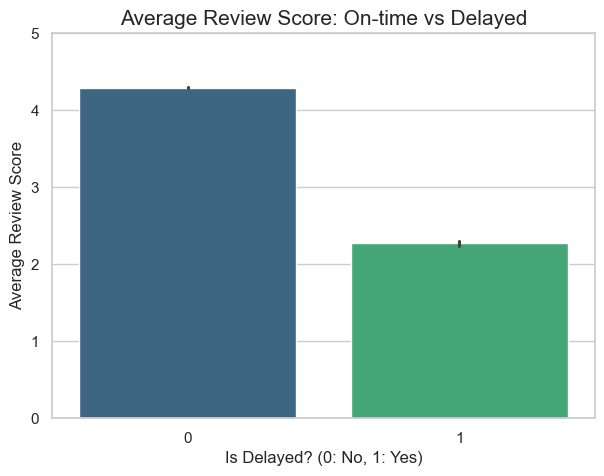

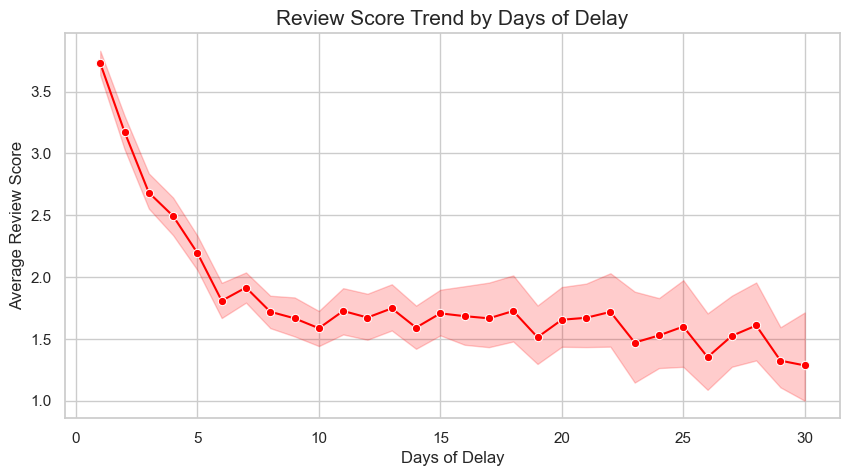

Excelファイル '物流と顧客満足度の相関分析' を作成しました


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- データの読み込み ---
orders = pd.read_csv(r'data\data_analysis_ec\data\olist_orders_dataset.csv')
reviews = pd.read_csv(r'data\data_analysis_ec\data\olist_order_reviews_dataset.csv')

# 1. 注文データとレビューデータを結合しコピーを作成
df = pd.merge(orders, reviews, on='order_id', how='inner').copy()

# --- データクレンジング ---

# 2. 日付型への変換
date_columns = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_columns:
    df[col] = pd.to_datetime(df[col])

# 3. 欠損値（注文キャンセル等）を除去した新しいデータフレームを作成
df_clean = df.dropna(subset=['order_delivered_customer_date']).copy()

# 4. 各種日数の計算（配送にかかった日数、遅延日数、「遅延したかどうか」のフラグ作成）
df_clean['delivery_days'] = (df_clean['order_delivered_customer_date'] - df_clean['order_purchase_timestamp']).dt.days
df_clean['delay_days'] = (df_clean['order_delivered_customer_date'] - df_clean['order_estimated_delivery_date']).dt.days
df_clean['is_delayed'] = df_clean['delay_days'].apply(lambda x: 1 if x > 0 else 0)

# --- 分析の実行 ---
print("--- 配送遅延の有無と平均スコア ---")
print(df_clean.groupby('is_delayed')['review_score'].mean())
# グラフのスタイル設定
sns.set_theme(style="whitegrid")

# 5. 配送遅延の有無による平均スコアの比較
plt.figure(figsize=(7, 5))
sns.barplot(x='is_delayed', y='review_score', hue='is_delayed', data=df_clean, palette='viridis', legend=False)
plt.title('Average Review Score: On-time vs Delayed', fontsize=15)
plt.xlabel('Is Delayed? (0: No, 1: Yes)', fontsize=12)
plt.ylabel('Average Review Score', fontsize=12)
plt.ylim(0, 5) 
plt.show()

# 6. 遅延日数とスコアの関係（折れ線グラフ）
plt.figure(figsize=(10, 5))
delay_only = df_clean[df_clean['delay_days'].between(1, 30)]
sns.lineplot(x='delay_days', y='review_score', data=delay_only, marker='o', color='red')
plt.title('Review Score Trend by Days of Delay', fontsize=15)
plt.xlabel('Days of Delay', fontsize=12)
plt.ylabel('Average Review Score', fontsize=12)
plt.grid(True)
plt.show()

# ---Excelレポートの出力---

# 7. 配送遅延の有無による平均スコア（サマリー）
delay_summary = df_clean.groupby('is_delayed')['review_score'].mean().reset_index()
delay_summary.columns = ['遅延フラグ（０：なし １：あり）', '平均レビュースコア']

# 2. 遅延日数ごとの調査委スコア（トレンド分析）
# 1日～30日の遅延データに絞って集計
delay_trend_data = df_clean[df_clean['delay_days'].between(1, 30)].groupby('delay_days')['review_score'].mean().reset_index()
delay_trend_data.columns = ['遅延日数', '平均レビュースコア']

# 3. Excelファイルとして保存
with pd.ExcelWriter('物流と顧客満足度の相関分析.xlsx') as writer:
    delay_summary.to_excel(writer, sheet_name='Delay_Summary', index=False)
    delay_trend_data.to_excel(writer, sheet_name='Delay_Trend_Datails', index=False)

print("Excelファイル '物流と顧客満足度の相関分析' を作成しました")